In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date

import matplotlib.cm as cm
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather

from aquacrop_slovenia import config
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_gdd_and_yield, \
    plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_rakican import rakican_soil_layers, rakican_curve_number, \
    rakican_readily_evaporable_water, rakican_maize_params, rakican_optimal_management, rakican_initial_cond, \
    rakican_groundwater
from aquacrop_slovenia.diagnostics import nse, kge, mkge

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
# Set up working directory for outputs
output_dir = config.RAMDISK_DIR / "testing_daily_rakican"
LOCATION = "rakican"

In [4]:
# Single year for daily inspection. Excluded years: 1998, 2023, 2017.
year = 1993
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 4, 20),
        "is_seeding_year": True,
    }
]

In [5]:
rakican_temperatures, rakican_eto, rakican_rain = get_station_weather(355)  # Rakičan uses ARSO meteo station 355

In [6]:
historical_co2 = get_co2_for_aquacrop("historical")

In [7]:
rakican_weather = Weather(
    location=LOCATION,
    temperatures=rakican_temperatures,
    eto_values=rakican_eto,
    rainfall_values=rakican_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2
)

In [8]:
rakican_maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=rakican_maize_params
)

In [9]:
rakican_soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil uncalibrated",
    soil_layers=rakican_soil_layers,
    curve_number=rakican_curve_number,
    readily_evaporable_water=rakican_readily_evaporable_water
)

In [10]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=rakican_maize,
    soil=rakican_soil,
    management=rakican_optimal_management,
    initial_conditions=rakican_initial_cond,
    climate=rakican_weather,
    #ground_water=rakican_groundwater,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [11]:
# Run the simulation
results = simulation.run()
seasonal_results = results["season"]

Setting up working directory at: E:\aquacrop\testing_daily_rakican
Running AquaCrop simulation with project file: E:\aquacrop\testing_daily_rakican\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: E:\aquacrop\testing_daily_rakican\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [12]:
seasonal_results

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,1993,413.9,754.2,1726.1,355.97,0.0,401.7,...,45.5,11.005,13.259,2.74,0.0,0.0,10,10,1993,PROJECT.PRM


In [13]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(2.00),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,1993,-9,0,378.3,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
1,2,1,1993,-9,0,377.5,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,1993,-9,0,376.9,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
3,4,1,1993,-9,0,378.0,1.4,0.0,0.0,1.4,...,None,None,None,None,None,None,None,None,None,None
4,5,1,1993,-9,0,378.6,0.6,0.0,0.0,0.6,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,6,10,1993,-9,0,268.0,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
279,7,10,1993,-9,0,267.0,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
280,8,10,1993,-9,0,266.1,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
281,9,10,1993,-9,0,264.6,1.0,0.0,0.0,1.0,...,None,None,None,None,None,None,None,None,None,None


<Axes: >

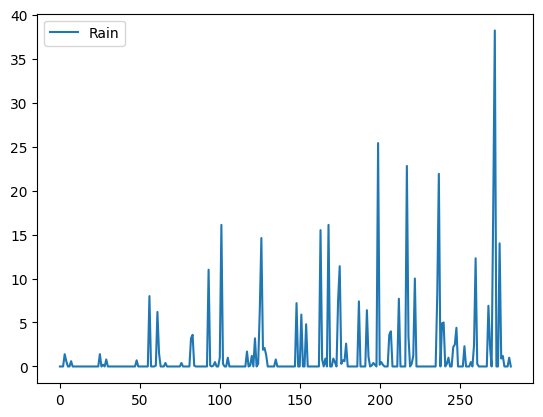

In [14]:
results["day"].plot(y="Rain")

<Axes: >

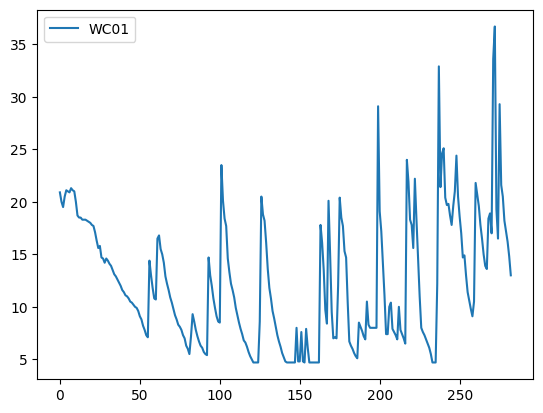

In [15]:
results["day"].plot(y="WC01")

<Axes: >

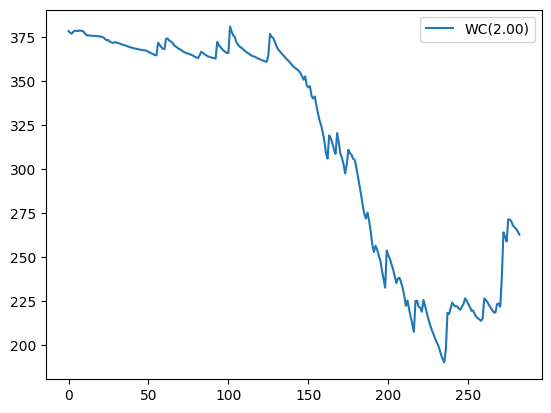

In [17]:
results["day"].plot(y="WC(2.00)")

<Axes: >

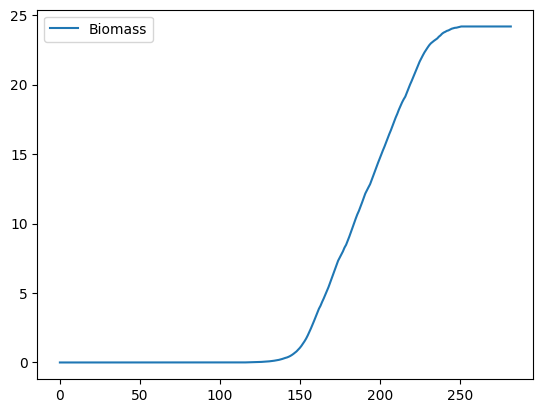

In [18]:
results["day"].plot(y="Biomass")

<Axes: >

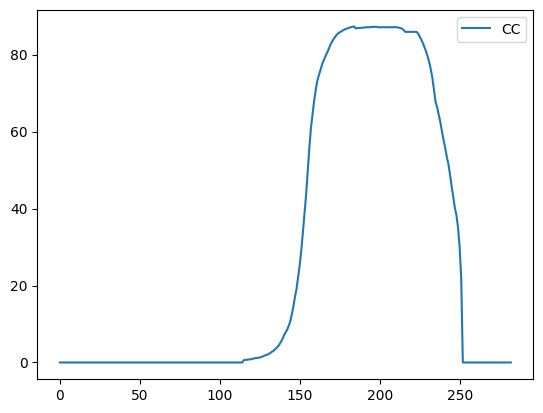

In [19]:
results["day"].plot(y="CC")

<Axes: >

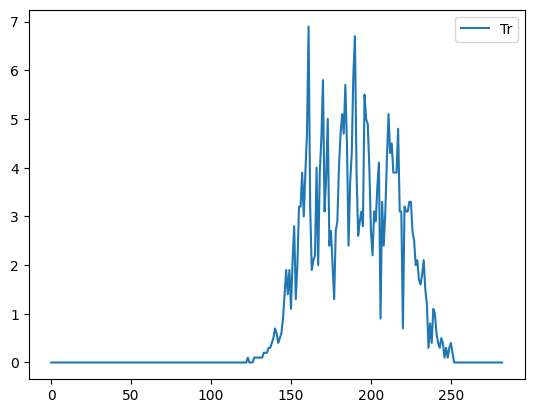

In [20]:
results["day"].plot(y="Tr")

<Axes: >

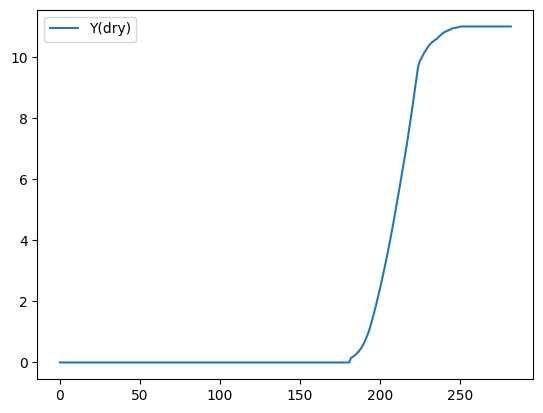

In [21]:
results["day"].plot(y="Y(dry)")

In [22]:
# GDD parameter sensitivity sweep — one param at a time, five values each
# Defaults: gdd_emergence=38, gdd_max_rooting=1207, gdd_senescence=1193,
#           gdd_maturity=1466, gdd_cycle_length=1466, gdd_flowering=660,
#           gdd_flowering_length=164, gdd_hi_start=595
gdd_sweep_params = {
    "gdd_emergence":        [20, 29, 38, 47, 56],
    "gdd_max_rooting":      [1025, 1116, 1207, 1298, 1390],
    "gdd_senescence":       [1000, 1097, 1193, 1290, 1385],
    "gdd_maturity":         [1245, 1356, 1466, 1576, 1685],
    "gdd_cycle_length":     [1265, 1366, 1466, 1566, 1666],
    "gdd_flowering":        [550, 605, 660, 715, 770],
    "gdd_flowering_length": [115, 140, 164, 188, 212],
    "gdd_hi_start":         [480, 538, 595, 652, 710],
}

INTEGER_PARAMS = {name for name, val in rakican_maize_params.items() if isinstance(val, int)}

MAX_WORKERS = os.cpu_count()
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.RAMDISK_DIR / f"daily_gdd_rakican_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

gdd_dir_queue = queue.Queue()
for d in worker_dirs:
    gdd_dir_queue.put(d)


def run_gdd_param(param_name, value):
    working_dir = gdd_dir_queue.get()
    try:
        params = copy.deepcopy(rakican_maize_params)
        params[param_name] = int(round(value)) if param_name in INTEGER_PARAMS else float(value)
        crop = Crop(name=f"{LOCATION} maize", description=f"{param_name}={value}", params=params)
        sim = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=rakican_soil,
            management=rakican_optimal_management,
            initial_conditions=rakican_initial_cond,
            climate=rakican_weather,
            #ground_water=rakican_groundwater,
            working_dir=working_dir,
            need_daily_output=True,
            need_seasonal_output=False,
            need_harvest_output=False,
            need_evaluation_output=False,
        )
        with contextlib.redirect_stdout(io.StringIO()):
            res = sim.run()
        daily = res["day"]
        return param_name, value, daily[daily["DAP"] >= 0].copy()
    finally:
        gdd_dir_queue.put(working_dir)


gdd_daily_results = {name: {} for name in gdd_sweep_params}

tasks = [(name, val) for name, values in gdd_sweep_params.items() for val in values]
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(run_gdd_param, name, val) for name, val in tasks]
    for future in as_completed(futures):
        param_name, value, daily = future.result()
        gdd_daily_results[param_name][value] = daily

print("Done.")

Results successfully parsed


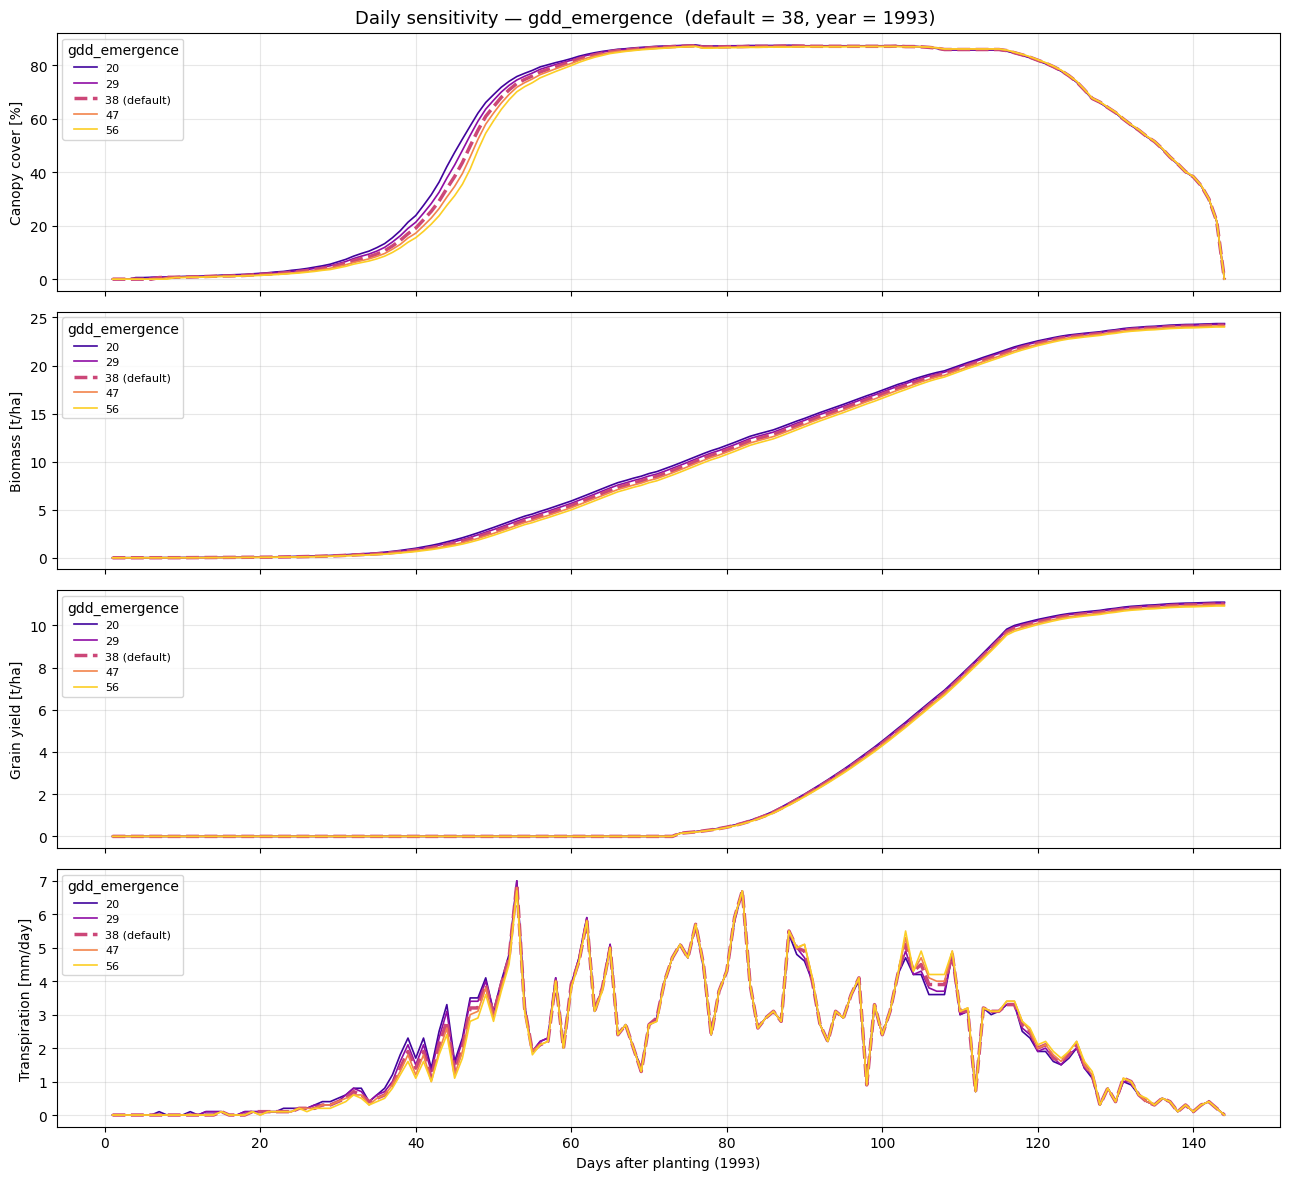

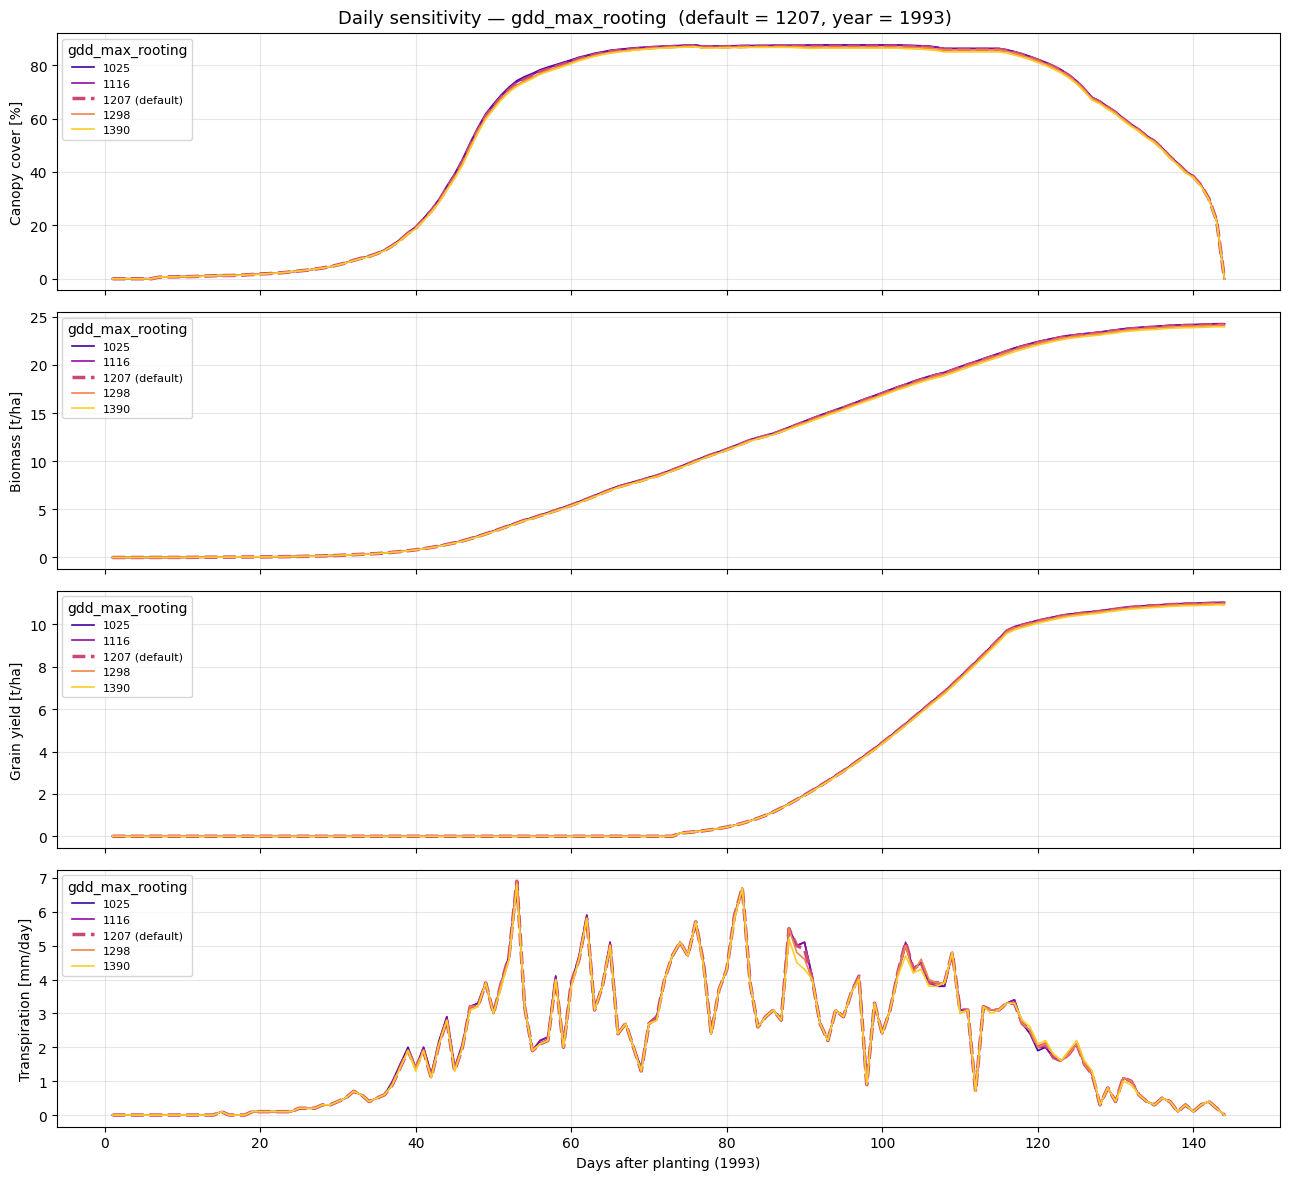

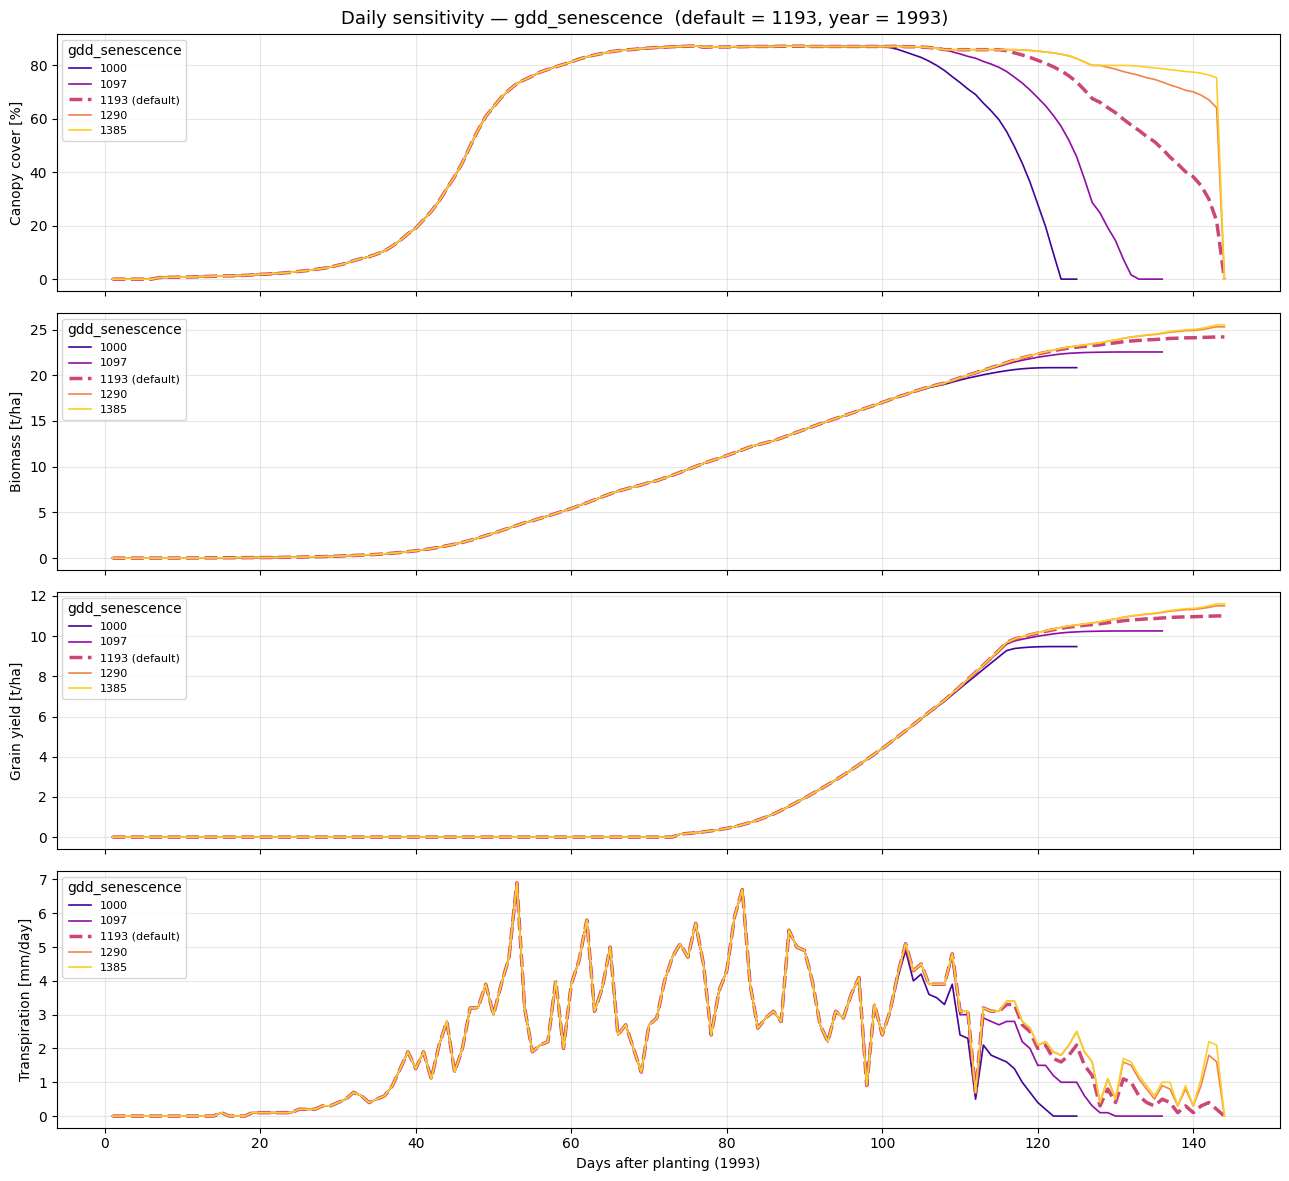

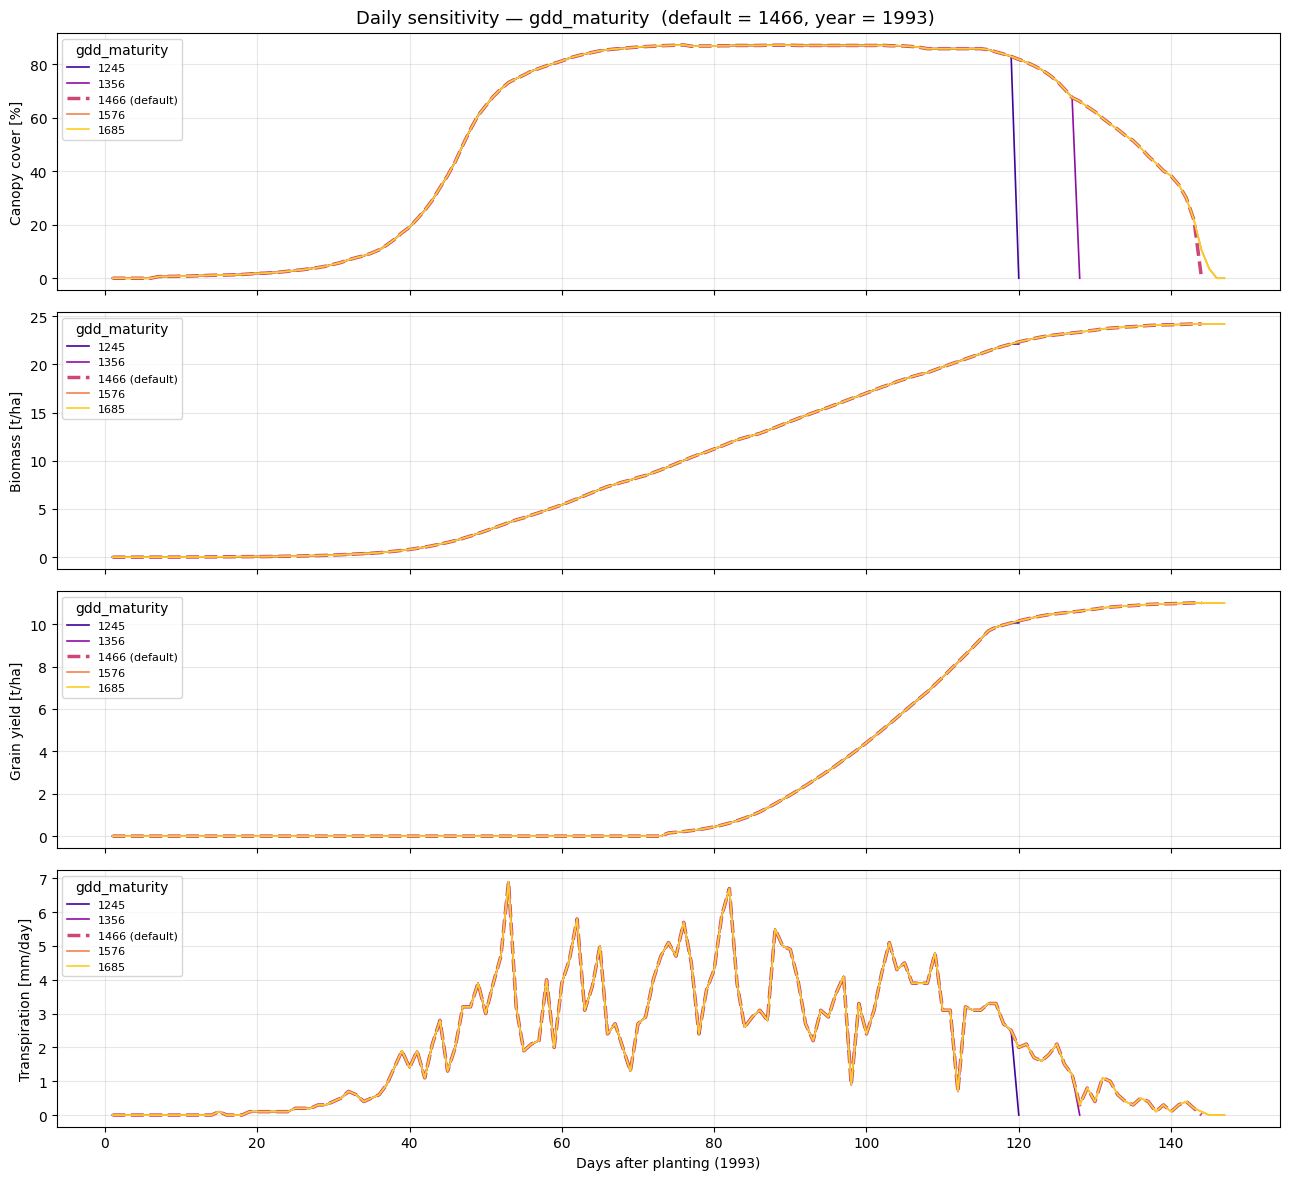

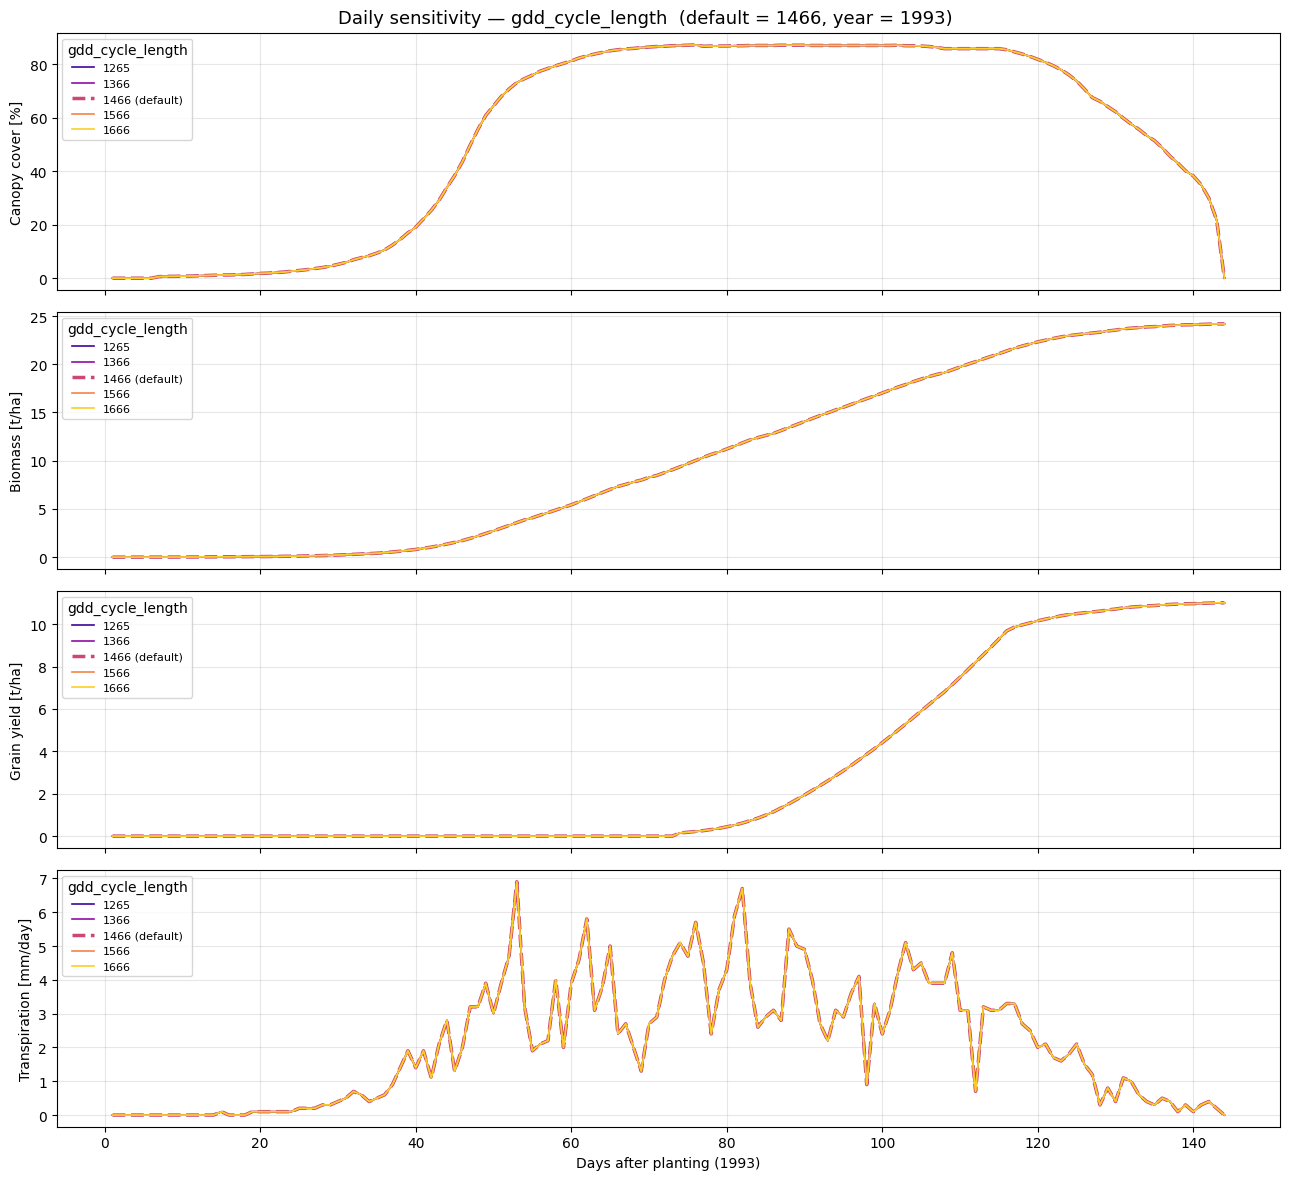

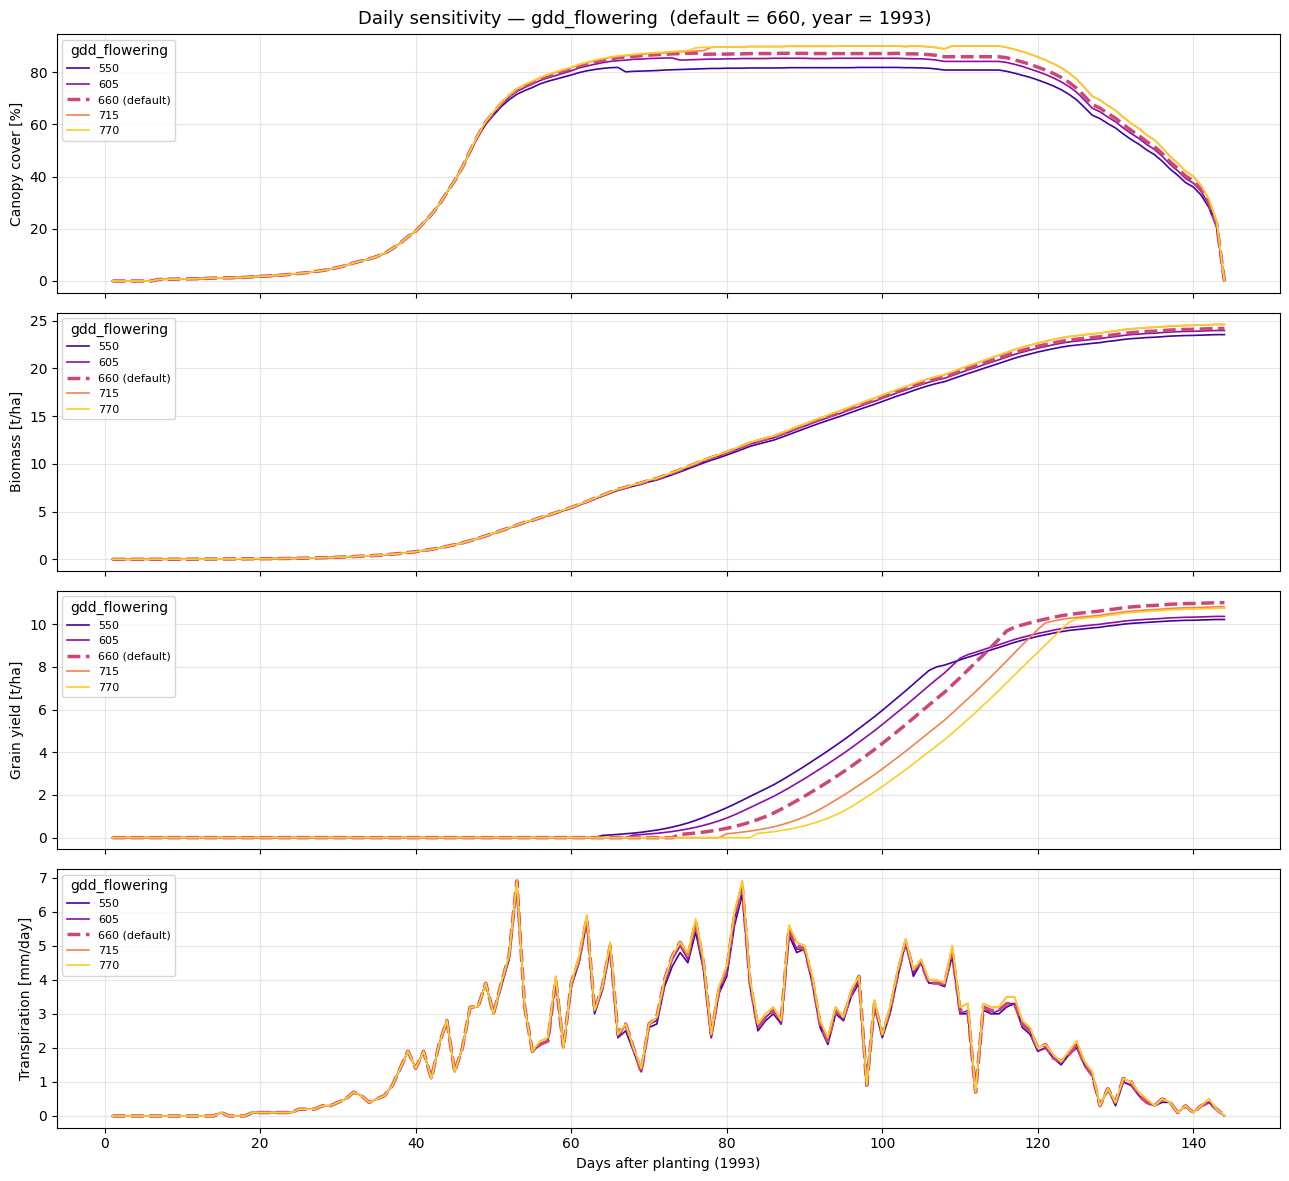

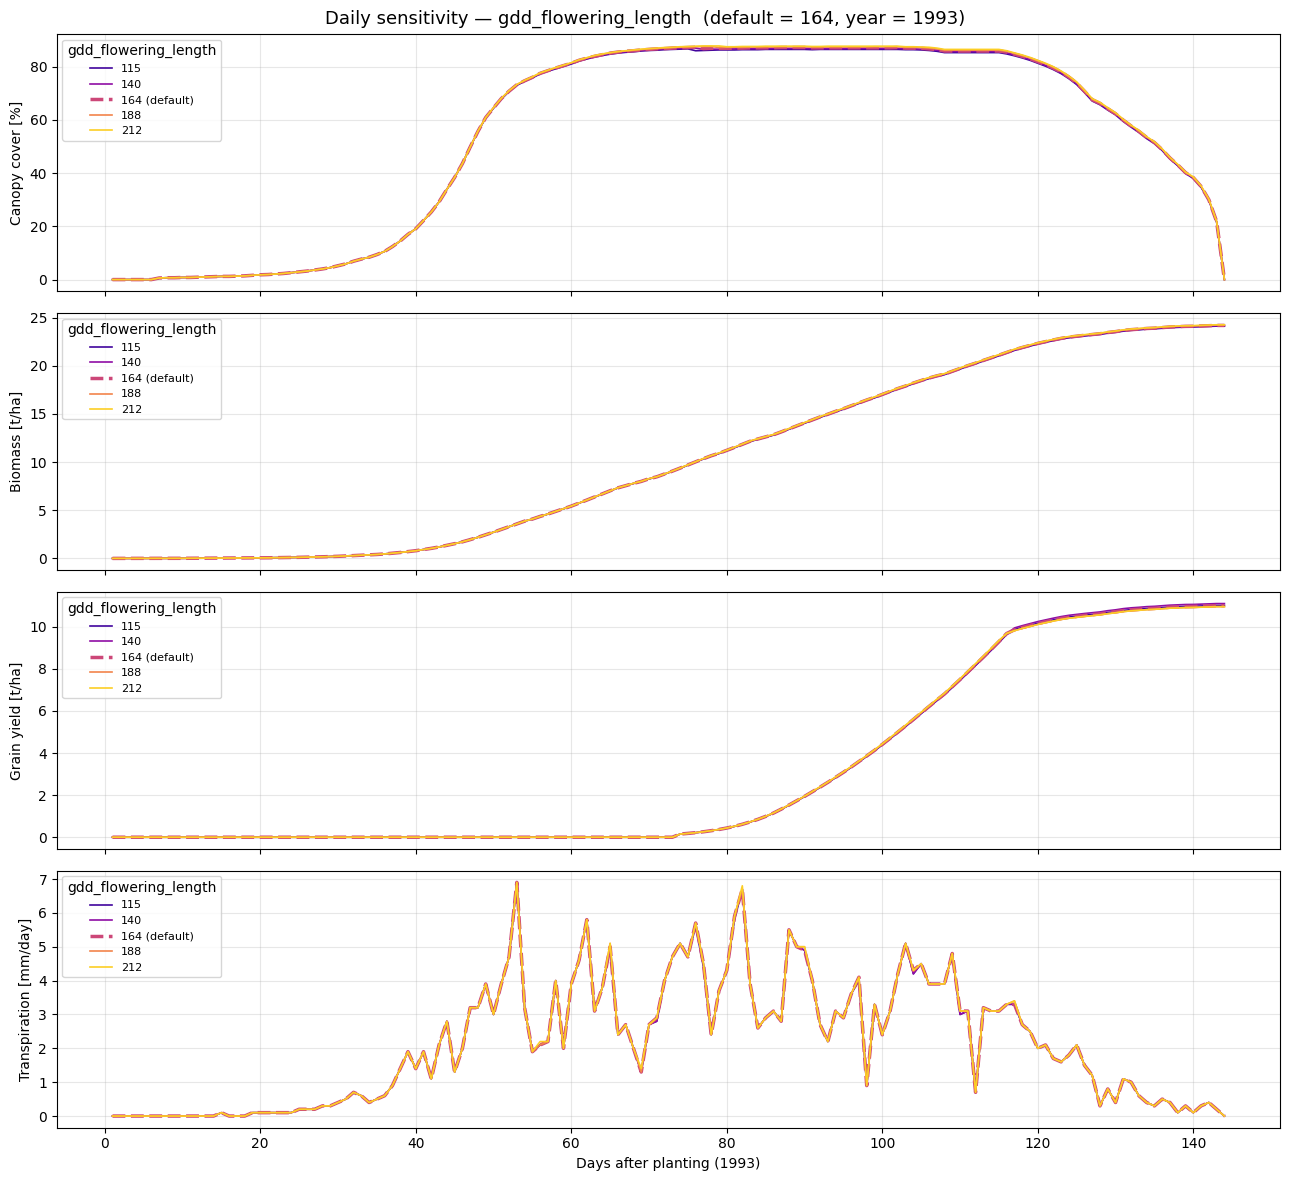

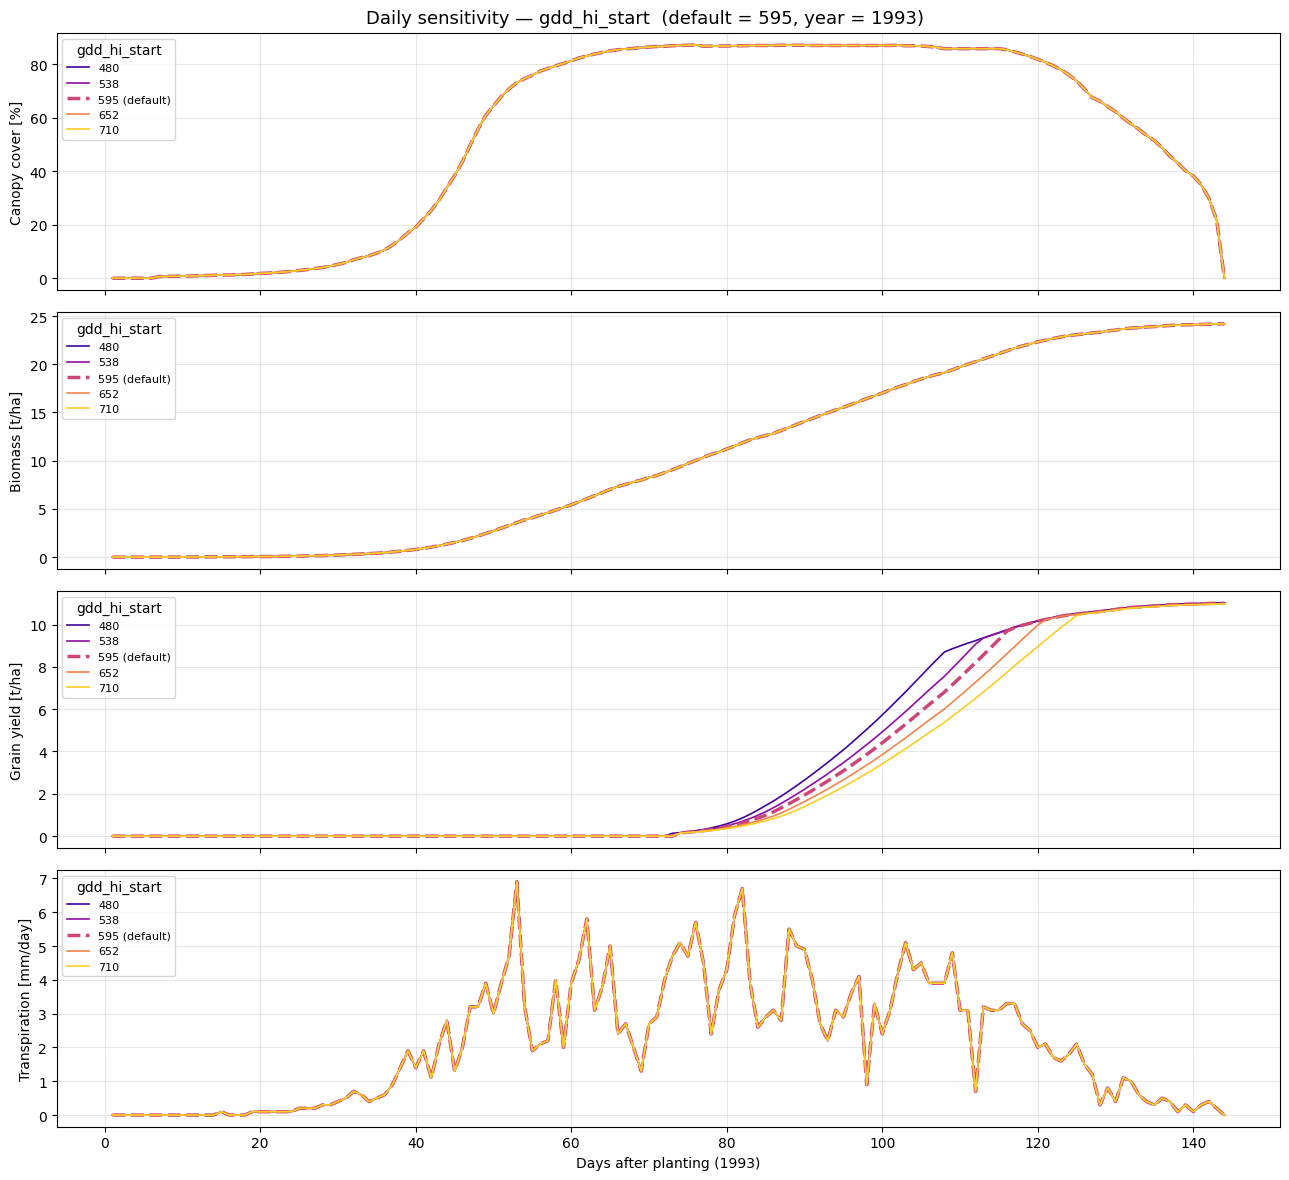

In [23]:
daily_panels = [
    ("CC",      "Canopy cover [%]"),
    ("Biomass", "Biomass [t/ha]"),
    ("Y(dry)",  "Grain yield [t/ha]"),
    ("Tr",      "Transpiration [mm/day]"),
]

for param_name, results_by_value in gdd_daily_results.items():
    values = sorted(results_by_value.keys())
    default_val = rakican_maize_params[param_name]
    colors = cm.plasma(np.linspace(0.1, 0.9, len(values)))

    fig, axes = plt.subplots(len(daily_panels), 1, figsize=(13, 3 * len(daily_panels)), sharex=True)
    fig.suptitle(
        f"Daily sensitivity — {param_name}  (default = {default_val}, year = {year})",
        fontsize=13,
    )

    for ax, (col, ylabel) in zip(axes, daily_panels):
        for val, color in zip(values, colors):
            daily = results_by_value[val]
            lw = 2.5 if val == default_val else 1.2
            ls = "--" if val == default_val else "-"
            ax.plot(
                daily["DAP"].values,
                daily[col].values,
                color=color,
                linewidth=lw,
                linestyle=ls,
                label=f"{val:.4g}" + (" (default)" if val == default_val else ""),
            )
        ax.set_ylabel(ylabel)
        ax.legend(title=param_name, fontsize=8, loc="upper left")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel(f"Days after planting ({year})")
    plt.tight_layout()
    plt.show()